## Occupation distance analysis

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- how to calculate average skill profile of 3D groups from Nesta matrix?
- wouldnt i need to start from the occ-skills matrix?

Decision
- use ESCO Skill-Occupation Matrix Tables for the start
- directly maps from 125 ISCO 3D occupations to 290 ESCO skill groups

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.5)
pd.options.display.float_format = '{:,.2f}'.format

# load paths
from src import utils
from src.data.framework import Esco
useful_paths = utils.UsefulPaths()

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

Prepare occupation-skills matrix

In [2]:
%%time

from src.data.framework import Esco
esco = Esco()

# Read occupations with their ISCO level
occ = esco.occupations
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix

# choose OSM version (weighted/unweighted)
osm_version = "weighted"

# read bipartite adjecency matrix for occupations and skills
occ_skills_mat = esco.read_occ_skills_matrix(return_version=osm_version)

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(occ_skills_mat.index.get_level_values(1)).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose())

# Find labels for isco codes
isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(str), columns=["code"]),
    esco.isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left"
)

arrays = [isco_groups_labels.conceptUri.values, isco_groups_labels.preferredLabel.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# to df
df_occ_sims_isco3 = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)

CPU times: total: 4.19 s
Wall time: 3.91 s


,code,conceptUri,preferredLabel
0,011,http://data.europa.eu/esco/isco/C011,Commissioned armed forces officers
1,021,http://data.europa.eu/esco/isco/C021,Non-commissioned armed forces officers
2,031,http://data.europa.eu/esco/isco/C031,"Armed forces occupations, other ranks"
3,111,http://data.europa.eu/esco/isco/C111,Legislators and senior officials
4,112,http://data.europa.eu/esco/isco/C112,Managing directors and chief executives
...,...,...,...
120,941,http://data.europa.eu/esco/isco/C941,Food preparation assistants
121,951,http://data.europa.eu/esco/isco/C951,Street and related service workers
122,952,http://data.europa.eu/esco/isco/C952,Street vendors (excluding food)
123,961,http://data.europa.eu/esco/isco/C961,Refuse workers


Threshholds

In [3]:
q_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.616368047779022 6.500853535353546


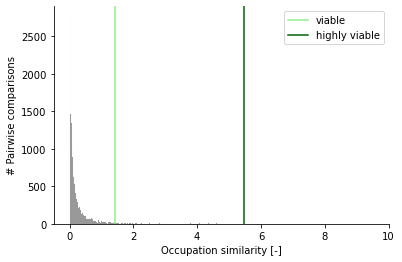

In [5]:
ax = sns.histplot(df_occ_sims_isco3.values.flatten(), color="grey")
ax.set_xlim(-0.5, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Occupation similarity [-]")
plt.legend()
sns.despine()

Coreness data

In [4]:
# todo: refactor to point to MCC repository data
coreness = pd.read_csv(os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"), index_col=0)
coreness_top_10 = coreness.sort_values("coreness", ascending=False).head(10)
coreness_top_10

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness,skill_classification_esco
12391,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/e54ff029-1ce9...,skill/competence,cross-sector,train employees,train an employee\nteach employees\nupskill em...,NaN,released,2021-10-01T16:36:38.559Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Lead and guide employees through a process in ...,0.95,"2,295,023.03",0.87,0.91,0.07,1.00,neutral
3572,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/415abd43-e8e5...,skill/competence,cross-sector,use different communication channels,apply specific communication channels\noperate...,NaN,released,2016-12-20T18:56:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Make use of various types of communication cha...,0.68,"2,624,645.09",1.00,0.84,0.06,0.93,neutral
2856,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/339ac029-066a...,skill/competence,cross-sector,manage staff,coordinate and monitor employees\nmanage subor...,NaN,released,2016-12-20T20:30:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Manage employees and subordinates, working in ...",0.82,"1,864,324.13",0.71,0.76,0.07,0.84,neutral
1821,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/21c5790c-0930...,skill/competence,cross-sector,manage budgets,NaN,NaN,released,2016-10-20T15:06:39Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Plan, monitor and report on the budget.",0.93,"1,523,320.43",0.58,0.75,0.08,0.82,neutral
732,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0da516ee-e70e...,skill/competence,cross-sector,communicate with customers,talk with customers\ncommunicate with clients\...,NaN,released,2021-12-16T09:30:47.116Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Respond to and communicate with customers in t...,0.85,"1,732,220.14",0.66,0.75,0.08,0.81,neutral
11144,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/cd5efa8c-e44d...,skill/competence,cross-sector,perform project management,perform management of projects\ndo project man...,NaN,released,2022-01-12T19:57:07.369Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/rese...,"Manage and plan various resources, such as hum...",1.00,"969,656.42",0.37,0.68,0.09,0.73,neutral
168,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/03b9b491-fc9b...,skill/competence,cross-sector,create solutions to problems,create solution to problems\nconceive solutio...,NaN,released,2021-09-15T14:08:49.35Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Solve problems which arise in planning, priori...",0.85,"1,288,734.78",0.49,0.67,0.09,0.72,neutral
7737,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/8d4271ca-c9fd...,knowledge,cross-sector,quality standards,NaN,NaN,released,2017-02-14T11:47:46Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"The national and international requirements, s...",0.83,"1,290,999.93",0.49,0.66,0.09,0.71,neutral
7986,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/918f5211-b99f...,skill/competence,cross-sector,write work-related reports,create work-related reports\nundertake work-re...,NaN,released,2020-12-07T16:31:40.896Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Compose work-related reports that support effe...,0.72,"1,413,239.03",0.54,0.63,0.08,0.69,neutral
2540,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/2de4572a-4724...,skill/competence,cross-sector,speak different languages,speak a different language\ncommunicate in mul...,NaN,released,2016-12-20T17:45:23Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Master foreign languages to be able to communi...,0.87,"1,075,017.89",0.41,0.64,0.09,0.69,neutral


#### Upskilling experiments

In [5]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

Q1: How many additional viable transitions are unlocked by adding different core skills (from top 10 list, one at a time)?

In [8]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

upskilling_impact = []

for occ_label, occ_code in threatened_occs.items():
    # find index of occ
    idx_occ = occ_codes.index(occ_code)
    
    for idx_new_skill, new_skill in coreness_top_10.iterrows():

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())

        # New viable transitions unlocked?
        n_new_viable_transitions = (np.tril(occ_sims_isco3_upskilling).flatten() > q_viable).sum() - (np.tril(df_occ_sims_isco3.values).flatten() > q_viable).sum()
        
        # collect data 
        upskilling_impact.append([occ_label, new_skill.preferred_label, n_new_viable_transitions])

In [9]:
df_upskilling_impact = pd.DataFrame(data=upskilling_impact, columns=["ISCO3D_label", "skill_label", "new_viable_transitions"])
df_upskilling_impact_pivoted = df_upskilling_impact.pivot_table(columns='ISCO3D_label', index='skill_label', values='new_viable_transitions')

<AxesSubplot:xlabel='skill_label', ylabel='ISCO3D_label'>

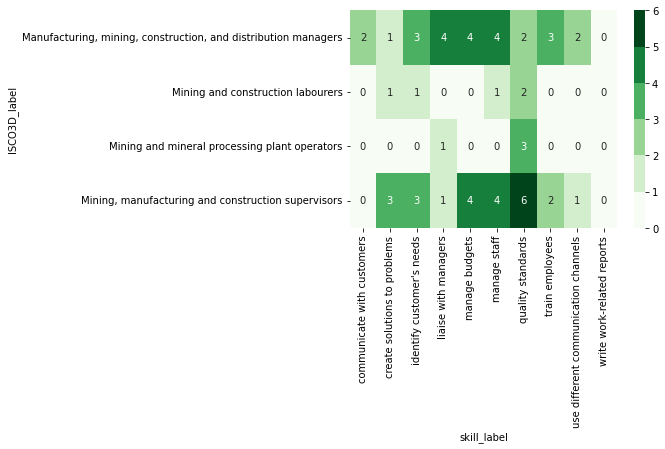

In [10]:
sns.heatmap(df_upskilling_impact_pivoted.transpose(), cmap=plt.get_cmap("Greens", 6), annot=True)

Q2: Which skill adds the most additional viable transitions per threatened occupation?

In [16]:
all_occs = {}

for i, s in isco_groups_labels.iterrows():
    all_occs[s.preferredLabel] = s.code

{'Commissioned armed forces officers': '011',
 'Non-commissioned armed forces officers': '021',
 'Armed forces occupations, other ranks': '031',
 'Legislators and senior officials': '111',
 'Managing directors and chief executives': '112',
 'Business services and administration managers': '121',
 'Sales, marketing and development managers': '122',
 'Production managers in agriculture, forestry and fisheries': '131',
 'Manufacturing, mining, construction, and distribution managers': '132',
 'Information and communications technology service managers': '133',
 'Professional services managers': '134',
 'Hotel and restaurant managers': '141',
 'Retail and wholesale trade managers': '142',
 'Other services managers': '143',
 'Physical and earth science professionals': '211',
 'Mathematicians, actuaries and statisticians': '212',
 'Life science professionals': '213',
 'Engineering professionals (excluding electrotechnology)': '214',
 'Electrotechnology engineers': '215',
 'Architects, planne

In [19]:
%%time

calc_upskilling_v2 = True
occ_codes = occ_skills_mat_isco3.index.values.tolist()

if calc_upskilling_v2:
    upskilling_impact_v2 = []
    for occ_label, occ_code in all_occs.items():
        print(occ_code, occ_label)
        # find index of occ
        idx_occ = occ_codes.index(occ_code)

        for idx_new_skill, new_skill in coreness.iterrows():

            # add skill to occ skill profile
            occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
            occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

            # recalc occ sim matrix
            occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())

            # New viable transitions unlocked?
            n_new_viable_transitions = (np.tril(occ_sims_isco3_upskilling).flatten() > q_viable).sum() - (np.tril(df_occ_sims_isco3.values).flatten() > q_viable).sum()

            # collect data 
            upskilling_impact_v2.append([occ_label, new_skill.preferredLabel, new_skill.coreness, n_new_viable_transitions])

    # to df
    df_upskilling_impact_v2 = pd.DataFrame(data=upskilling_impact_v2, columns=["ISCO3D_label", "skill_label", "coreness", "new_viable_transitions"])
    df_upskilling_impact_v2.to_csv(os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_all_skills_per_isco3d_occupation.csv"))

011 Commissioned armed forces officers
021 Non-commissioned armed forces officers
031 Armed forces occupations, other ranks
111 Legislators and senior officials
112 Managing directors and chief executives
121 Business services and administration managers
122 Sales, marketing and development managers
131 Production managers in agriculture, forestry and fisheries
132 Manufacturing, mining, construction, and distribution managers
133 Information and communications technology service managers
134 Professional services managers
141 Hotel and restaurant managers
142 Retail and wholesale trade managers
143 Other services managers
211 Physical and earth science professionals
212 Mathematicians, actuaries and statisticians
213 Life science professionals
214 Engineering professionals (excluding electrotechnology)
215 Electrotechnology engineers
216 Architects, planners, surveyors and designers
221 Medical doctors
222 Nursing and midwifery professionals
223 Traditional and complementary medicine 

#### Table for thesis: top 5 skills for unlocking new viable transitions for each occupation

In [26]:
top_skills_per_occ = []
for occ_label, occ_code in all_occs.items():
    top_skills = df_upskilling_impact_v2.loc[df_upskilling_impact_v2.ISCO3D_label == occ_label].sort_values("new_viable_transitions", ascending=False).head(5)
    top_skills_per_occ.append(top_skills)

# to table
df_top_skills_per_occ = pd.concat(top_skills_per_occ, axis=0)
df_top_skills_per_occ = df_top_skills_per_occ.rename(columns={"ISCO3D_label": "Occupation", "skill_label":"Skill", "coreness":"Coreness", "new_viable_transitions":"Viable transitions"})
df_top_skills_per_occ.reset_index(drop=True).to_csv(
    os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_best_5_skills_per_isco3d_occupation.csv"),
)

#### Add skills metadata
- gbn labels
- network metrics
- gbn shares of ISCO occupations

In [25]:
df_upskilling_impact_v2

,ISCO3D_label,skill_label,coreness,new_viable_transitions
0,Commissioned armed forces officers,manage musical staff,0.00,0
1,Commissioned armed forces officers,supervise correctional procedures,0.00,0
2,Commissioned armed forces officers,apply anti-oppressive practices,0.01,0
3,Commissioned armed forces officers,control compliance of railway vehicles regulat...,0.05,0
4,Commissioned armed forces officers,identify available services,0.00,0
...,...,...,...,...
1736370,Other elementary workers,remediate healthcare user's occupational perfo...,0.00,0
1736371,Other elementary workers,install transport equipment lighting,0.02,0
1736372,Other elementary workers,natural language processing,0.02,0
1736373,Other elementary workers,coordinate construction activities,0.06,0


In [20]:
from scipy import stats
stats.pearsonr(df_upskilling_impact_v2.coreness, df_upskilling_impact_v2.new_viable_transitions)

(0.12730145866997702, 0.0)

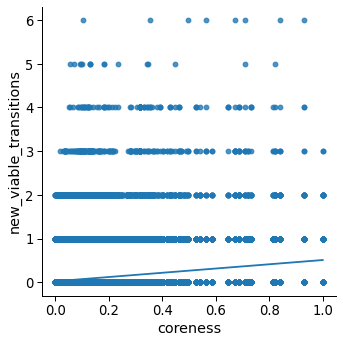

In [27]:
sns.lmplot(x="coreness", y="new_viable_transitions", x_ci="sd", data=df_upskilling_impact_v2)

In [24]:
import pingouin as pg
df_upskilling_impact_v2.rcorr()

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


,coreness,new_viable_transitions
coreness,-,***
new_viable_transitions,0.127,-


Text(0.5, 0, 'Target ISCO 3D groups')

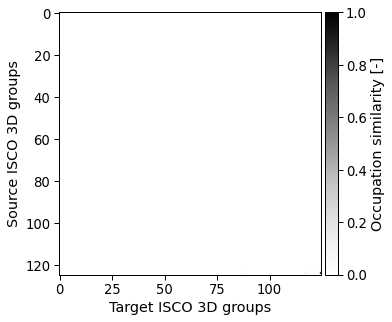

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.tril(occ_sims_isco3_upskilling - occ_sims_isco3), cmap="Greys", vmax=1)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Plots

Text(0.5, 0, 'Target ISCO 3D groups')

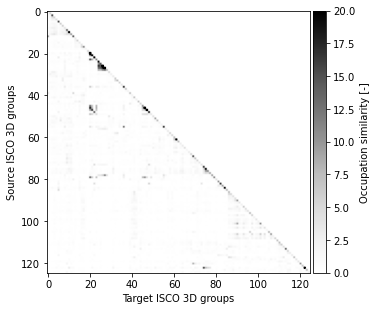

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.tril(df_occ_sims_isco3.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Aggregate skills coreness to ESCO skills hierarchy level 3

In [15]:
coreness.sort_values("coreness", ascending=False)

,preferred_label,reuse_level,code,skill_category,coreness
id,,,,,
3475,use different communication channels,cross-sector,S1.2.1,S,1.000000
12026,train employees,cross-sector,S1.3.3,S,0.939861
2778,manage staff,cross-sector,S4.8.1,S,0.931311
1776,manage budgets,cross-sector,S4.3.1,S,0.896653
710,communicate with customers,cross-sector,S3.4.1,S,0.854498
...,...,...,...,...,...
9988,take emergency measures in pregnancy,occupation-specific,S3.2.1,S,0.000000
4854,develop the look of a production,sector-specific,S1.12.3,S,0.000000
9983,assess structural integrity of ship for mariti...,occupation-specific,S2.8.1,S,0.000000


In [16]:
# TODO: needs to point to MCC dir
esco_skill_hierarchy = pd.read_csv(os.path.join(data_raw, "esco", "v1.0.8", "skillsHierarchy_en.csv"))
esco_skill_hierarchy.head()

,Level 0 URI,Level 0 preferred term,Level 1 URI,Level 1 preferred term,Level 2 URI,Level 2 preferred term,Level 3 URI,Level 3 preferred term,Description,Scope note,Level 0 code,Level 1 code,Level 2 code,Level 3 code
0,http://data.europa.eu/esco/skill/S,skills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN
1,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",NaN,NaN,NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,NaN,NaN
2,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,NaN
3,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0.0,"communication, collaboration and creativity","Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,S1.0.0
4,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.1,negotiating,NaN,NaN,Exchanging ideas while analysing issues and in...,NaN,S,S1,S1.1,NaN


Can get to the 290 lvl 3 skill groups by filtering for skill/competence skill types, dropping the attitudes and lastly dropping nan values

In [17]:
esco_skill_hierarchy_subset = esco_skill_hierarchy.loc[
    (esco_skill_hierarchy.skill_type == "skill/competence") &
    (esco_skill_hierarchy.skill_category == "S")
].dropna(subset=["level_3"])

AttributeError: 'DataFrame' object has no attribute 'skill_type'

In [ ]:
esco_skill_hierarchy_subset_coreness = pd.merge(
    esco_skill_hierarchy_subset,
    coreness[["preferred_label", "coreness"]],
    on="preferred_label",
    how="left"
)

In [ ]:
esco_weighted_coreness = esco_skill_hierarchy_subset_coreness.groupby("level_title").coreness.mean() / esco_skill_hierarchy_subset_coreness.groupby("level_title").count().coreness

Occupation similarity matrix based on ESCO occ skills tables

In [ ]:
occ_skill_table = pd.read_excel(
    os.path.join(data_raw, "esco", "en_Skills_Occupations Matrix Tables.xlsx"),
    sheet_name="Matrix 3.3"
)

# row multiindex
occ_skill_table = occ_skill_table.set_index(["Unnamed: 0", "Unnamed: 1"])
occ_skill_table.index.names = ["occ_uri", "occ"]

# column multiindex
col_indizes = [occ_skill_table.columns.values.tolist(), occ_skill_table.iloc[0, :].values.tolist()]
tuples = list(zip(*col_indizes))
col_index = pd.MultiIndex.from_tuples(tuples, names=["skill_uri", "skill"])
occ_skill_table.columns = col_index
occ_skill_table = occ_skill_table.iloc[1:, :]
occ_skill_table = occ_skill_table.astype(float)

# convert from fractions to percentages to avoid multiplication of values below 0
occ_skill_table *= 100

Correlation between occ skills tables and own co-occurrence matrix at ISCO 3 digit level

In [ ]:
occ_sims = np.matmul(occ_skill_table.values, occ_skill_table.values.transpose())
df_occ_sims = pd.DataFrame(index=occ_skill_table.index, columns=occ_skill_table.index, data=occ_sims)

In [ ]:
np.corrcoef(df_occ_sims_isco3.values.flatten(), df_occ_sims.values.flatten())